CASO PRATICO: INTERPOLAZIONE NELLO SPAZIO LATENTE CON VAE

Smettiamo di guarda sotto il cofano ed iniziamo a guidare la macchina.
Lo spazio lantente non è solo un ammasso di numero ma un continium di concetti.

- Walk latente: creazione di GIF per visualizzare trasformazioni fluide. Mostrano il passaggio tra entità diverse
- Algebra delle feature, fare aritmetica con i segnificati.
- Portare tutto questo fuori dal ns pc tramite il deployment.

Cosa significa camminare tra i pensieri della rete?
La vera forza di un VAE rispetto a un AE classico, è la sua regolarità
Non ci sono strappi, burroni nello spazio latente, questo permette di compiere wolk latente.
Possiamo scegliere due punti (es. n. 8 e 9) e tracciare un sentiero tra loro, lungo questo sentiero avremmo solo immagini sensate.

Come trasformiamo questo sentiero un un'animazione fluida?

Interpolazione e Animazione
Dallo scatto al filmato
L'interpolazione lineare tra due vettori latenti (LERT) definisce un segmento nello spazio a k dimensioni.
Scomponendo questo segmento in piccoli passi discreti, otteniamo una serie di codici (vettore latente) che il decoder trasformerà in frame. 
Assemblando questi frame in una GIF, visualizziamo la fluidità con cui la rete passa da un'identità all'altra.
La continuità visiva è la prova regina che l'addestramento ha eliminato le discontinuità tipiche degli autoencoder (AE) classici.
Vediamo la struttura stesssa che si trasforma, i pixel seguono la logica del manifold.

La fludità di questa GIF, dipende dalla risoluzione temporale. Aumentando il numero di passi intermedi, la transizione diventa più fluida, rivelando come l'AI interpreta i tratti intermedi. Più ho frame, più la transizione appare naturale.
Tuttavia, a volte, muoversi linea retta non è la scelta migliore.
Immagina di dover andare da un punto all'altro della terra, non scavi un tunnel dritto, ma segui la curvatura delle superficie.
Nello spazio latente gaussiano, a volte dobbiamo usare traiettorie non lineari per rimanere nelle zone dove la probabilità è più altta, evitando le periferie.
Qui entra in gioco un alternativa matematica

Analisi della Qualità
In molti casi, specie in zone ad alta densità, l'interpolazione sferica (SLERP) è spesso preferibile alla lineare (LERP) per muoversi lungo la superfice di una distribuzione gaussiana multidimensionale.
Questo perchè la distribuzione gaussiana tende a concentrarsi su una buccia sferica. Se andiamo dritti tagliamo per il centro dove i dati sono meno densi, rischiando di ottenere immagini intermedie sbiadite.
Lo SLERP garantisce che ogni frame abbia la stessa energia e nitidezza dei punti di partenza. E' come navigare lungo l'equatore, invece di trapanare il pianeta.
Questa tecnica mantiene costante la norma del vettore, garantendo che le immagini intermedie non perdano intensità o dettagli.

Algebra delle Feature
Sommarre e sottrarre concetti semantici.
Oltre a muoverci tra campioni esistenti (interpolazione), possiamo manipolare lo spazio latente per aggiungere o rimuovere attributi specifici dai dati.
Identificando la direzione vettoriale che rappresenta una feature, possiamo applicarla a qualsiasi nuovo campione in modo chirurgico.
Immagina di voler aggiungere gli occhiali ad una persona che non li indissa, dobbiamo trovare la direzione del concetto occhiali, nello spazio latente ed applicarla al codice della nostra immagine.

Vediamo come si estrare matematicamente un concetto da un insieme di numeri.

Aritmetica Latente
Operare sul significato.
Un vettore attributo si ottiene calcolando la differenza tra le medie di due gruppi di campioni (es. volti con occhiali vs senza occhiali.)
Sommando questo vettore a un codice z neutro, il decoder genererà l'immagine originale con l'attributo aggiunto.
Questo controllo semantico è possibile grazie alla struttura ordinata del manifold appresa durante il training.
L'algebra delle feature trasforma il VAE da semplice genereatore casuale a strumento di editing guidato.
Stiamo operando direttamente sul significato.

Isolamento degli Attributi
Il successo di questa operazione (capacità di modificare un solo tratto senza alterare gli altri) dipende dal Disentanglement, ovvero da quanto sono disaccoppiate le dimensioni latenti, cioè da quanto bene la rete è riuscita ad isolare i diversi tratti.
Se le dimensioni sono ben separate, aggiungere un sorriso non cambierà il colore dei capelli o l'eta di un soggetto.
Possiamo anche regolare l'intensità (es. quanto è marcato un sorriso) tramite un coefficiente scalare alfa (intensità della modifica dell'attributo).
E' un controllo semantico 

C'è anche un modo specifico per addestrare questi modelli affinchè questa algebra sia più pulita.

Feature Algebra e Beta-VAE
Pressione statistica e controllo
I modelli addestrati con un beta elevato, (peso maggiore sulla KL loss) mostrano un'aritmetica latente molto più pulita/precisa rispetto ai VAE standard.
L'indipendenza forzata delle dimensioni riduce il rischio che l'aggiunta di un attributo causi effetti collaterali indesiderati sulla ricostruzione.

Ora che sappiamo manipolare i sogni dell'ai, come li portiamo nel mondo reale?

Deployment del Decoder
Mettere l'AI generativa nella mani dell'utente
Per creare un'applicazone interattiva, non abbiamo bisogno dell'intera architettura. Il solo decoder è sufficiente per generare contenuti in tempo reale.
Un valota finito l'addestramento il decoder è un modulo autonomo e leggerissimo, non serve più l'encoder e non serve più nemmeno il dataset originale.
Il decoder è una semplice funzione matematica, che mappa pochi numeri in un'immagine completa.
Questo lo rende perfetto per applicazioni in tempo reale.
Dove l'utente può esplorare lo spazio latente senza aver bisogno di hardware superpotente
E' possibile esportare questo componente (decoder) e integrarla in un'interfaccia web leggere e reattiva.

Export e Ottimizzazione
Portabilità del modello
- Freeze del modello: isoliamo i pesi del decoder e blocchiamo il calcolo dei gradienti per ridurre l'uso di memoria.
- Esportiamo i pesi (decoder) in formati standard come ONNX o TensorFlow.js permettendo l'esecuzione diretta nel browser dell'utente.
L'interfaccia utente può usare degli slider per permettere all'utente di muovresi nello spazio latente interattivamente.
Il decoder agisce come una funzione matematica leggere che mappa coordinate vettoriali in immagini.

Interazione in Tempo Reale.
I decoder VAE sono solitamente piccoli e veloci, rendendo possibile una risposta immediata ai comandi dell'utente (latenza di generazione).
Fornire i controlli visivi per lo spazio latente, permette agli utenti di 'esplorare' la creatività dell'AI senza scrivere codice (user experience).
L'esecuzione AI lato client garantisce la privacy dei dati dell'utente e riduce i costi di infrastruttura server.
I dati non lasciano mai il computer e si risparmiano i costo di infrastruttura claude.

Possiamo spingerci oltre con l'ottimizzazione?

Per rendere il modello ancora più snello per i dispositivi mobili, usiamo la quantizzazione dei pesi a 8 bit (dai pesi a 32 bit, decimali complessi). Questo riduce il file del 75% 
Questo permette di caricare modelli generativi complessi anche su dispositivi mobili con risorse senza perdita visibili di qualità.

Inizio fase di addestramento Beta-VAE...
Epoca 1/20 completata. Perdita media: 344.0265
Epoca 2/20 completata. Perdita media: 292.2613
Epoca 3/20 completata. Perdita media: 283.4033
Epoca 4/20 completata. Perdita media: 279.3134
Epoca 5/20 completata. Perdita media: 277.3330
Epoca 6/20 completata. Perdita media: 276.0815
Epoca 7/20 completata. Perdita media: 275.1769
Epoca 8/20 completata. Perdita media: 274.4103
Epoca 9/20 completata. Perdita media: 274.0219
Epoca 10/20 completata. Perdita media: 273.4680
Epoca 11/20 completata. Perdita media: 273.1116
Epoca 12/20 completata. Perdita media: 272.8028
Epoca 13/20 completata. Perdita media: 272.6217
Epoca 14/20 completata. Perdita media: 272.2701
Epoca 15/20 completata. Perdita media: 272.1407
Epoca 16/20 completata. Perdita media: 271.9153
Epoca 17/20 completata. Perdita media: 271.6633
Epoca 18/20 completata. Perdita media: 271.6124
Epoca 19/20 completata. Perdita media: 271.3816
Epoca 20/20 completata. Perdita media: 271.2836


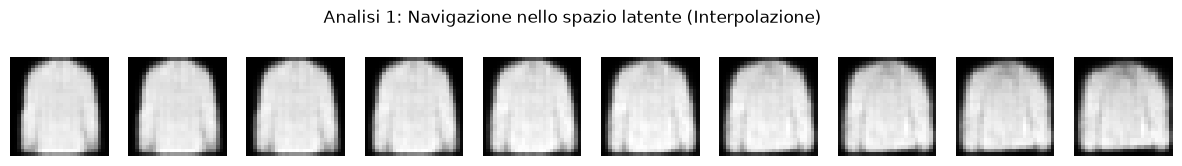

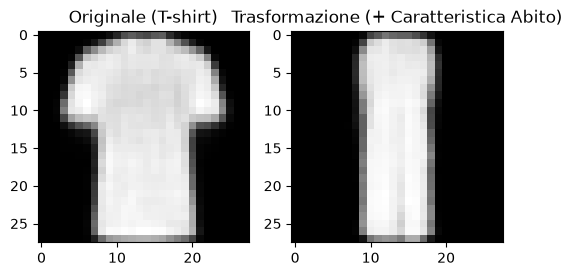

C:\Users\barbara\AppData\Local\Temp\ipykernel_48488\4073583875.py:188: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_decoder = torch.quantization.quantize_dynamic(
c:\EPICODE\Epicode_Python_AI_MachineLearning\.venv\Lib\site-packages\torch\ao\nn\quantized\modules\utils.py:72: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized 


--- Esportazione completata: decoder_fashion_quant.pt (8-bit) pronto per il deployment ---


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# --- CONFIGURAZIONE DEL SISTEMA ---
# Selezione del dispositivo di calcolo: GPU se disponibile, altrimenti CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dimensione del vettore latente (lo spazio compresso dove il modello impara le caratteristiche).
latent_dim = 32

# Parametro Beta per il disentanglement: controlla quanto il modello deve separare le singole 
# caratteristiche (es. forma, dimensione) nel vettore latente. Un valore > 1 forza una maggiore separazione.
beta = 4.0

# Numero di epoche per l'addestramento.
epochs = 20

# Caricamento del dataset FashionMNIST (immagini di abiti 28x28 in scala di grigi).
# Applichiamo una trasformazione ToTensor per convertire le immagini in tensori PyTorch (0.0 - 1.0).
transform = transforms.Compose([transforms.ToTensor()])
train_loader = torch.utils.data.DataLoader(
    datasets.FashionMNIST('.', train=True, download=True, transform=transform),
    batch_size=128, 
    shuffle=True
)

# --- ARCHITETTURA MODELLO: FashionBVAE ---
# Il Beta-VAE è composto da due parti principali: un Encoder che comprime i dati
# e un Decoder che cerca di ricostruirli partendo dalla rappresentazione compressa.
class FashionBVAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim
        
        # L'Encoder trasforma l'immagine di input (28x28) in due parametri statistici:
        # la media (mu) e il logaritmo della varianza (logvar).
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 4, stride=2, padding=1), # 14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, 4, stride=2, padding=1), # 7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, latent_dim * 2)
        )
        
        # Il Decoder riceve un punto dello spazio latente e rigenera l'immagine 28x28.
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1), # 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 4, stride=2, padding=1), # 28x28
            nn.Sigmoid()
        )

    def encode(self, x):
        """
        Passa l'immagine attraverso l'encoder per ottenere 
        la media e la varianza della distribuzione latente.
        """
        h = self.encoder(x)
        # Suddividiamo l'output in due parti uguali: mu e logvar
        mu, logvar = h.chunk(2, dim=-1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        Il cuore del VAE: campiona un punto 'z' dalla distribuzione definita da mu e logvar.
        Si usa il trucco della riparametrizzazione per permettere il passaggio del gradiente:
        z = mu + epsilon * deviazione_standard
        """
        std = torch.exp(0.5 * logvar) # Calcolo della deviazione standard dal logaritmo della varianza
        eps = torch.randn_like(std)   # Campionamento di rumore casuale normale
        return mu + eps * std

    def forward(self, x):
        """
        Definisce il flusso del dato: Input -> Encoder -> Reparametrizzazione -> Decoder -> Output.
        """
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        # Restituiamo la ricostruzione, la media e la varianza (necessarie per la loss function)
        return self.decoder(z), mu, logvar

# --- PROCEDURA DI ADDESTRAMENTO ---
# Inizializzazione del modello e dell'ottimizzatore Adam.
model = FashionBVAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Inizio fase di addestramento Beta-VAE...")
model.train()
for epoch in range(epochs):
    total_loss = 0
    for data, _ in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        # Esecuzione del modello sull'input corrente
        recon, mu, logvar = model(data)
        
        # La Loss del BVAE è composta da due parti:
        # 1. Recon Loss: misura quanto l'immagine ricostruita è fedele all'originale.
        recon_loss = F.binary_cross_entropy(recon, data, reduction='sum')
        
        # 2. KLD Loss: misura quanto la distribuzione latente si allontana da una Normale standard.
        # Viene moltiplicata per 'beta' per controllare il grado di disentanglement.
        kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        
        # Somma delle due componenti per il calcolo del gradiente
        loss = recon_loss + beta * kld_loss
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoca {epoch+1}/{epochs} completata. Perdita media: {total_loss/len(train_loader.dataset):.4f}")

# --- ANALISI 1: LATENT WALK (Morphing tra immagini) ---
@torch.no_grad()
def latent_walk_visualization(model, z1, z2, steps=10):
    """
    Visualizza la transizione fluida tra due punti distinti nello spazio latente.
    Mostra come il decoder interpreta i punti intermedi tra z1 e z2.
    """
    model.eval()
    plt.figure(figsize=(15, 2))
    # Creiamo un'interpolazione lineare tra i due vettori latenti
    for i, t in enumerate(torch.linspace(0, 1, steps)):
        z = (1 - t) * z1 + t * z2
        img = model.decoder(z).squeeze().cpu() # Passaggio dal decoder all'immagine
        plt.subplot(1, steps, i + 1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.suptitle("Analisi 1: Navigazione nello spazio latente (Interpolazione)")
    plt.show()

# --- ANALISI 2: ALGEBRA DELLE CARATTERISTICHE (Feature Arithmetic) ---
@torch.no_grad()
def feature_algebra_visualization(model, loader):
    """
    Dimostra la capacità del modello di isolare e manipolare attributi specifici.
    Calcoliamo un 'vettore di differenza' tra due categorie per applicarlo a nuovi dati.
    """
    model.eval()
    # Raccogliamo vettori latenti per "T-shirt" (Classe 0) e "Abiti lunghi" (Classe 3)
    z_tshirt, z_dress = [], []
    for data, labels in loader:
        data = data.to(device)
        mu, _ = model.encode(data)
        z_tshirt.append(mu[labels == 0])
        z_dress.append(mu[labels == 3])
        if len(z_tshirt) > 10 and len(z_dress) > 10: break
    
    # Il vettore differenza cattura l'essenza della "lunghezza/stile" di un abito rispetto a una maglietta
    v_feature = torch.cat(z_dress).mean(0) - torch.cat(z_tshirt).mean(0)
    
    # Prendiamo una maglietta originale
    z_orig = torch.cat(z_tshirt)[0:1]
    # Aggiungiamo il 'vettore abito' alla maglietta per trasformarla artificialmente
    z_mod = z_orig + 2.0 * v_feature 
    
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(model.decoder(z_orig).squeeze().cpu(), cmap='gray')
    plt.title("Originale (T-shirt)")
    plt.subplot(1, 2, 2)
    plt.imshow(model.decoder(z_mod).squeeze().cpu(), cmap='gray')
    plt.title("Trasformazione (+ Caratteristica Abito)")
    plt.show()

# --- ESPORTAZIONE: DEPLOYMENT (Quantizzazione e TorchScript) ---
def export_for_deployment(model):
    """
    Applica la quantizzazione dinamica a 8 bit ed esporta il decoder in formato TorchScript.
    Questo riduce la dimensione dei pesi (Linear) migliorando la velocità su CPU.
    """
    model.eval()
    
    # Spostiamo il modello su CPU per la quantizzazione (requisito standard)
    model_cpu = model.cpu()
    
    # Applichiamo la quantizzazione dinamica ai layer Linear per convertirli a 8-bit (int8)
    quantized_decoder = torch.quantization.quantize_dynamic(
        model_cpu.decoder, 
        {nn.Linear}, 
        dtype=torch.qint8
    )
    
    # Creiamo un input fittizio su CPU per tracciare il decoder quantizzato
    example_z = torch.randn(1, latent_dim)
    traced_decoder = torch.jit.trace(quantized_decoder, example_z)
    traced_script = torch.jit.script(traced_decoder)
    
    # Salvataggio del modello serializzato e quantizzato
    traced_script.save("decoder_fashion_quant.pt")
    print("\n--- Esportazione completata: decoder_fashion_quant.pt (8-bit) pronto per il deployment ---")

# --- AVVIO DELLE ANALISI ---
# Generiamo due punti casuali nello spazio latente per il morphing
z_start = torch.randn(1, latent_dim).to(device)
z_end = torch.randn(1, latent_dim).to(device)

# Esecuzione delle visualizzazioni e dei test di esportazione
latent_walk_visualization(model, z_start, z_end)
feature_algebra_visualization(model, train_loader)
export_for_deployment(model)